# Exercício Prático 1
### Eduardo Santos Birchal
### Matrícula: 2024023970

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# OLS 1D

## Definições de Função

In [17]:
def calc_mse(y_true, y_pred):
    # erro quadratico medio
    return np.mean((y_true - y_pred)**2)

def calc_mae(y_true, y_pred):
    # erro absoluto medio
    return np.mean(np.abs(y_true - y_pred))

def calc_r2(y_true, y_pred):
    # coeficiente de determinacao r2
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

def add_intercept(x):
    # adiciona coluna de uns a esquerda da matriz x
    n = x.shape[0]
    return np.column_stack((np.ones(n), x))

In [18]:
def plotar_resultados(x, y, y_hat, residuos):
    # criacao da figura com dois subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # grafico 1: ajuste linear
    ax1.scatter(x, y, color='blue', label='dados originais', alpha=0.6)
    ax1.plot(x, y_hat, color='red', label='reta de regressao')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('ajuste linear (OLS 1D)')
    ax1.legend()

    # grafico 2: distribuicao dos residuos
    ax2.hist(residuos, bins=20, color='gray', edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--', label='media zero')
    ax2.set_xlabel('residuo')
    ax2.set_ylabel('frequencia')
    ax2.set_title('distribuicao dos residuos')
    ax2.legend()

    # ajuste do layout e exibicao
    plt.tight_layout()
    plt.show()

## Leitura e preparação dos dados

In [19]:
df = pd.read_csv('data/secao1.csv')

x = df['x'].values
y = df['y'].values

# construindo matriz de projeto adicionando a coluna de intercepto
X = add_intercept(x)

## Resolução por equações normais

In [20]:
# beta = (X^T X)^-1 X^T y
X_t = X.T
beta = np.linalg.inv(X_t @ X) @ X_t @ y

beta_0 = beta[0]
beta_1 = beta[1]

print("valores dos parametros estimados:")
print(f"intercepto (beta_0): {beta_0:.4f}")
print(f"inclinacao (beta_1): {beta_1:.4f}\n")

valores dos parametros estimados:
intercepto (beta_0): 2.4910
inclinacao (beta_1): 1.6986



## Predições e resíduos

In [21]:
# calculo de prediçoes
y_hat = X @ beta

# vetor de residuos
residuos = y - y_hat

## Avaliação

In [22]:
mse = calc_mse(y, y_hat)
mae = calc_mae(y, y_hat)
r2 = calc_r2(y, y_hat)

# exibindo os resultados das metricas em formato de tabela
metricas_df = pd.DataFrame({
    'metrica': ['MSE', 'MAE', 'R2'],
    'valor': [mse, mae, r2]
})

print("tabela de metricas de avaliacao:")
print(metricas_df.to_string(index=False))

tabela de metricas de avaliacao:
metrica    valor
    MSE 1.015470
    MAE 0.802501
     R2 0.954779


## Visualicações

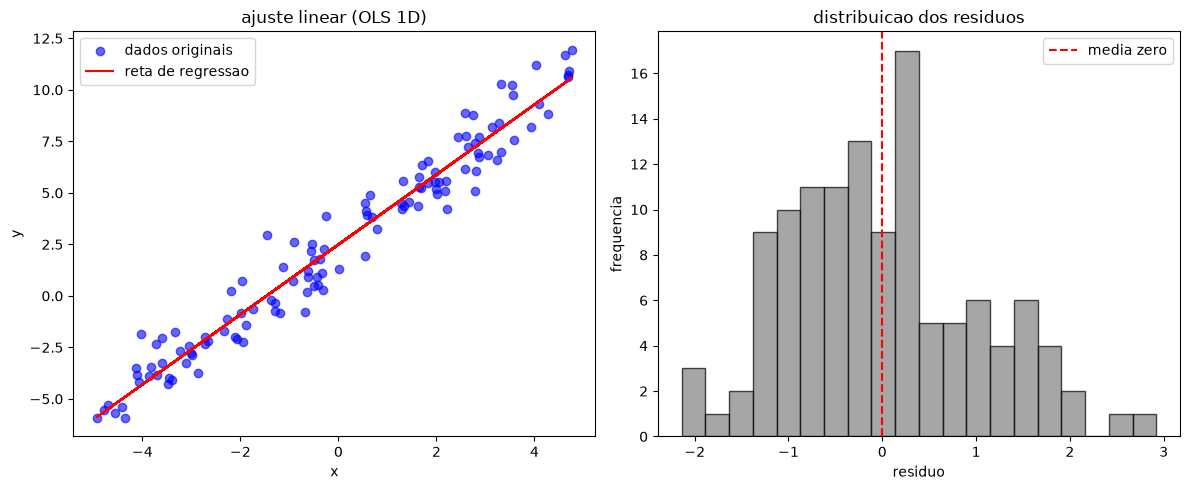

In [23]:
plotar_resultados(x, y, y_hat, residuos)

# Multicolinearidade, Regime n<p e Ridge Regression

## Definições de função

In [24]:
def fit_ridge(x, y, lambda_val):
    # ajusta ridge regression penalizando apenas os preditores
    p = x.shape[1]
    i_prime = np.eye(p)
    i_prime[0, 0] = 0.0 # sem penalizacao no intercepto
    
    x_t = x.T
    beta = np.linalg.inv(x_t @ x + lambda_val * i_prime) @ x_t @ y
    return beta


## Fazendo o setup

In [25]:
np.random.seed(42)

df2 = pd.read_csv('data/secao2.csv')
x2 = df2[['x1', 'x2']].values
y2 = df2['y'].values

x2_ext = add_intercept(x2)
n2 = x2_ext.shape[0]

## Holdout manual 70/30

In [26]:
indices = np.random.permutation(n2)
split_idx = int(0.7 * n2)

train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

x_train = x2_ext[train_idx]
y_train = y2[train_idx]

x_test = x2_ext[test_idx]
y_test = y2[test_idx]

# modelo ols no treino (lambda = 0)
beta_ols = fit_ridge(x_train, y_train, 0.0)

y_pred_train = x_train @ beta_ols
y_pred_test = x_test @ beta_ols

mse_train = calc_mse(y_train, y_pred_train)
mse_test = calc_mse(y_test, y_pred_test)

print("coeficientes ols (lambda=0):")
print(f"beta_0 (intercepto): {beta_ols[0]:.4f}")
print(f"beta_1: {beta_ols[1]:.4f}")
print(f"beta_2: {beta_ols[2]:.4f}\n")

mse_df = pd.DataFrame({
    'conjunto': ['treino', 'teste'],
    'mse': [mse_train, mse_test]
})
print("tabela comparativa mse (ols):")
print(mse_df.to_string(index=False))

coeficientes ols (lambda=0):
beta_0 (intercepto): 2.9487
beta_1: 1.7859
beta_2: 0.1991

tabela comparativa mse (ols):
conjunto      mse
  treino 1.050950
   teste 1.047149


## Caminho dos coeficientes via Ridge

In [27]:
lambdas_path = [0.0, 1e-3, 1e-2, 1e-1]
betas_path = []

for l in lambdas_path:
    b = fit_ridge(x_train, y_train, l)
    betas_path.append(b)
    
betas_path = np.array(betas_path)

coef_path_df = pd.DataFrame({
    'lambda': lambdas_path,
    'beta_1': betas_path[:, 1],
    'beta_2': betas_path[:, 2]
})

print("caminho dos coeficientes preditores:")
print(coef_path_df.to_string(index=False))
print("\n")

# grafico caminho dos coeficientes
plt.figure(figsize=(8, 5))
plt.plot(lambdas_path, betas_path[:, 1], marker='o', label='beta_1')
plt.plot(lambdas_path, betas_path[:, 2], marker='s', label='beta_2')
plt.xlabel('lambda')
plt.ylabel('valor do coeficiente')
plt.title('caminho dos coeficientes (ridge)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('caminho_coeficientes.png')
plt.close()

caminho dos coeficientes preditores:
 lambda   beta_1   beta_2
  0.000 1.785931 0.199068
  0.001 1.779522 0.205478
  0.010 1.726191 0.258816
  0.100 1.429811 0.554842




## Regime n<p

In [28]:
df3 = pd.read_csv('data/secao3.csv')
y3 = df3['y'].values
x3 = df3.drop('y', axis=1).values

x3_ext = add_intercept(x3)
n3, p3 = x3_ext.shape

# evidencia da falha do ols
x3_t = x3_ext.T
x3_t_x3 = x3_t @ x3_ext
print(f"dimensoes de x: {n3} amostras, {p3} atributos (incluindo intercepto)")
print(f"condicao n < p verificada: {n3 < p3}\n")

try:
    np.linalg.inv(x3_t_x3)
except np.linalg.LinAlgError as e:
    print("erro ao inverter x^t x:")
    print(f"np.linalg.LinAlgError: {e}\n")

cond_number = np.linalg.cond(x3_t_x3)
print(f"numero de condicionamento de x^t x: {cond_number:.2e}")
if cond_number > 1e10:
    print("matriz mal condicionada! isso justifica instabilidade no ols.\n")

dimensoes de x: 12 amostras, 21 atributos (incluindo intercepto)
condicao n < p verificada: True

numero de condicionamento de x^t x: 1.24e+18
matriz mal condicionada! isso justifica instabilidade no ols.



## Validação cruzada manual

In [29]:
k = 4
indices3 = np.random.permutation(n3)
folds = np.array_split(indices3, k)

lambdas_cv = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
mean_mse_cv = []

for l in lambdas_cv:
    fold_mses = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        x_tr, y_tr = x3_ext[train_idx], y3[train_idx]
        x_val, y_val = x3_ext[val_idx], y3[val_idx]
        
        b = fit_ridge(x_tr, y_tr, l)
        y_pred = x_val @ b
        
        fold_mses.append(calc_mse(y_val, y_pred))
        
    mean_mse_cv.append(np.mean(fold_mses))
    
cv_df = pd.DataFrame({
    'lambda': lambdas_cv,
    'mse_medio_val': mean_mse_cv
})

print("resultados da validacao cruzada (k=4):")
print(cv_df.to_string(index=False))

best_idx = np.argmin(mean_mse_cv)
best_lambda = lambdas_cv[best_idx]
print(f"\nmelhor lambda encontrado: {best_lambda}")

# grafico
plt.figure(figsize=(8, 5))
plt.semilogx(lambdas_cv, mean_mse_cv, marker='o', linestyle='-', color='purple')
plt.axvline(x=best_lambda, color='red', linestyle='--', label=f'lambda otimo ({best_lambda})')
plt.xlabel('lambda (escala log)')
plt.ylabel('mse medio (validacao)')
plt.title('validacao cruzada ridge regression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('validacao_cruzada.png')
plt.close()

resultados da validacao cruzada (k=4):
  lambda  mse_medio_val
  0.0001      36.417197
  0.0010      35.988387
  0.0100      33.061243
  0.1000      25.218867
  1.0000      17.427614
 10.0000      10.304216
100.0000       8.707523

melhor lambda encontrado: 100


## Ajuste final em todos os dados

In [30]:
beta_final = fit_ridge(x3_ext, y3, best_lambda)

y_pred_final = x3_ext @ beta_final

mse_final = calc_mse(y3, y_pred_final)
mae_final = calc_mae(y3, y_pred_final)
r2_final = calc_r2(y3, y_pred_final)

metricas_finais_df = pd.DataFrame({
    'metrica': ['MSE', 'MAE', 'R2'],
    'valor': [mse_final, mae_final, r2_final]
})

print("metricas finais no conjunto completo (secao3.csv):")
print(metricas_finais_df.to_string(index=False))

metricas finais no conjunto completo (secao3.csv):
metrica    valor
    MSE 5.661747
    MAE 2.013541
     R2 0.151700
